In [15]:
import json
from pathlib import Path
from typing import Dict, Optional

import lama_aesthetics
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import Dataset
from lama_aesthetics.plotutils import range_frame
from scipy.constants import golden

from scipy.constants import golden

ONE_COL_WIDTH_INCH = 3
TWO_COL_WIDTH_INCH = 7.25
ONE_COL_GOLDEN_RATIO_HEIGHT_INCH = ONE_COL_WIDTH_INCH / golden
TWO_COL_GOLDEN_RATIO_HEIGHT_INCH = TWO_COL_WIDTH_INCH / golden


## Combine QA scores

In [3]:
ENV_DIRS = [
    "afm_qa",
    "catalyst_qa",
    "md_qa",
    "ml_qa",
    "resistor_qa",
    "retro_qa",
    "spectra_qa",
]

MODEL_DIRS = ["gpt", "claude"]

MODEL_LABELS = {
    "gpt": "GPT-4o",
    "claude": "Claude 3.5 Sonnet",
    
}

COLOR_PALETTE = {
    "GPT-4o": "#a285a6",  # GPT-4o
    "Claude-4.5": "#768eab",  # Claude-3.5
    "gpt": "#a285a6",  # GPT-4o
    "claude": "#768eab",  # Claude-3.5
    "react" : "#4D2FB2",  # React
    "tool_calling": "#F375C2",  # Tool Calling
}

In [68]:
df.agent.unique()

array(['react', 'tool_calling'], dtype=object)

In [5]:
def load_score_from_summary(summary_path: Path) -> Optional[float]:
    """Load overall_score from summary.json (fallback benchmark_score)."""
    if not summary_path.exists():
        return None

    try:
        with summary_path.open() as f:
            data = json.load(f)
    except Exception as e:
        print(f"[WARN] Failed to read {summary_path}: {e}")
        return None

    return data.get("overall_score", data.get("benchmark_score", None))


def find_latest_timestamp_run(reports_dir: Path) -> Optional[Path]:
    """Return latest timestamped run directory inside reports/ (ignoring topic_reports)."""
    if not reports_dir.exists():
        return None

    candidates = [
        p for p in reports_dir.iterdir() if p.is_dir() and p.name != "topic_reports"
    ]
    if not candidates:
        return None

    return sorted(candidates)[-1]

def resolve_summary_path(reports_dir: Path) -> Optional[Path]:
    """
    Resolve summary.json path supporting both layouts:
      A) reports/topic_reports/summary.json
      B) reports/<timestamp>/topic_reports/summary.json  (latest timestamp)
    """
    # Layout A
    direct = reports_dir / "topic_reports" / "summary.json"
    if direct.exists():
        return direct

    # Layout B
    latest_run = find_latest_timestamp_run(reports_dir)
    if latest_run is None:
        return None

    candidate = latest_run / "topic_reports" / "summary.json"
    if candidate.exists():
        return candidate

    return None

def extract_env_model_scores(root: Path) -> Dict[str, Dict[str, float]]:
    """
    Returns:
        scores[env][model] = overall_score
    """
    scores: Dict[str, Dict[str, float]] = {}

    print("\n[INFO] Searching for summary.json files...\n")

    for env in ENV_DIRS:
        env_path = root / env
        if not env_path.exists():
            print(f"[SKIP] Missing env directory: {env_path}")
            continue

        scores[env] = {}

        for model in MODEL_DIRS:
            reports_dir = env_path / model / "reports"
            summary_path = resolve_summary_path(reports_dir)

            if summary_path is None:
                print(
                    f"[MISS] {env}/{model}: No summary.json found under {reports_dir}"
                )
                continue

            score = load_score_from_summary(summary_path)
            if score is None:
                print(
                    f"[MISS] {env}/{model}: summary.json exists but no score in {summary_path}"
                )
                continue

            scores[env][model] = score
            print(f"[FOUND] {env}/{model}: {score:.4f}  ({summary_path})")

    return scores

In [10]:
root = Path(".").resolve()
path = root / "qa"
scores = extract_env_model_scores(path)



[INFO] Searching for summary.json files...

[FOUND] afm_qa/gpt: 0.8800  (/Users/n0w0f/git/n0w0f_2026/mat-agent-bench/reports_v2/qa/afm_qa/gpt/reports/topic_reports/summary.json)
[FOUND] afm_qa/claude: 0.8800  (/Users/n0w0f/git/n0w0f_2026/mat-agent-bench/reports_v2/qa/afm_qa/claude/reports/topic_reports/summary.json)
[FOUND] catalyst_qa/gpt: 0.8600  (/Users/n0w0f/git/n0w0f_2026/mat-agent-bench/reports_v2/qa/catalyst_qa/gpt/reports/topic_reports/summary.json)
[FOUND] catalyst_qa/claude: 0.8800  (/Users/n0w0f/git/n0w0f_2026/mat-agent-bench/reports_v2/qa/catalyst_qa/claude/reports/topic_reports/summary.json)
[FOUND] md_qa/gpt: 0.9412  (/Users/n0w0f/git/n0w0f_2026/mat-agent-bench/reports_v2/qa/md_qa/gpt/reports/topic_reports/summary.json)
[FOUND] md_qa/claude: 0.9412  (/Users/n0w0f/git/n0w0f_2026/mat-agent-bench/reports_v2/qa/md_qa/claude/reports/topic_reports/summary.json)
[FOUND] ml_qa/gpt: 0.7400  (/Users/n0w0f/git/n0w0f_2026/mat-agent-bench/reports_v2/qa/ml_qa/gpt/reports/topic_reports

In [18]:
new_scores = {}
for env, model_scores in scores.items():
    k = env.replace("_qa", "")
    new_scores[k] = model_scores


In [19]:
new_scores

{'afm': {'gpt': 0.88, 'claude': 0.88},
 'catalyst': {'gpt': 0.86, 'claude': 0.88},
 'md': {'gpt': 0.9411764705882353, 'claude': 0.9411764705882353},
 'ml': {'gpt': 0.74, 'claude': 0.74},
 'resistor': {'gpt': 0.7419354838709677, 'claude': 0.9032258064516129},
 'retro': {'gpt': 0.6888888888888889, 'claude': 0.8444444444444444},
 'spectra': {'gpt': 0.46226415094339623, 'claude': 0.8113207547169812}}

In [12]:
df = pd.read_csv("science_agent_metrics.csv")

In [21]:
df.environment.unique()

array(['spectra', 'resistor', 'retrosynthesis', 'catalyst', 'afm', 'ml',
       'md', 'wetlab'], dtype=object)

In [22]:
df.model.unique()

array(['Claude-4.5', 'GPT-4o'], dtype=object)

In [23]:
new_scores

{'afm': {'gpt': 0.88, 'claude': 0.88},
 'catalyst': {'gpt': 0.86, 'claude': 0.88},
 'md': {'gpt': 0.9411764705882353, 'claude': 0.9411764705882353},
 'ml': {'gpt': 0.74, 'claude': 0.74},
 'resistor': {'gpt': 0.7419354838709677, 'claude': 0.9032258064516129},
 'retro': {'gpt': 0.6888888888888889, 'claude': 0.8444444444444444},
 'spectra': {'gpt': 0.46226415094339623, 'claude': 0.8113207547169812}}

In [24]:
# how to add a column called qa_score to each entry in the data frame score is assigned based on environment and model
for index, row in df.iterrows():
    env = row["environment"]
    model = row["model"]
    env_key = env.lower()
    m = model.lower()
    if "gpt" in m:
        model_key = "gpt"
    elif "claude" in m:
        model_key = "claude"
    else:
        model_key = m
    qa_score = new_scores.get(env_key, {}).get(model_key, None)
    df.at[index, "qa_score"] = qa_score

In [89]:
df

,model,environment,agent,subtype,level,verbosity,task_type,prompt_tokens,completion_tokens,total_tokens,...,total_tasks,tool_verbosity,total_tool_calls,successful_tool_calls,failed_tool_calls,surrendered_trials,total_tool_execution_duration,total_benchmark_duration,qa_score,qa_score_z
0,Claude-4.5,spectra,react,NaN,level_1,workflow,tasks,1706955,44992,1751947,...,20,workflow,1360,1360,0,0.0,2762.076723,16455.705800,0.811321,-0.546767
1,Claude-4.5,spectra,react,NaN,level_1,workflow,subtasks,3814045,540399,4354444,...,200,workflow,2376,2337,39,0.0,3736.919208,39248.201375,0.811321,-0.546767
2,Claude-4.5,spectra,react,NaN,level_1,brief,tasks,944865,52382,997247,...,20,brief,1139,1139,0,0.0,4177.036238,17183.919920,0.811321,-0.546767
3,Claude-4.5,spectra,react,NaN,level_1,brief,subtasks,2173094,500450,2673544,...,200,brief,2563,2544,19,0.0,5250.689175,39783.796771,0.811321,-0.546767
4,Claude-4.5,spectra,react,NaN,level_1,comprehensive,tasks,1977048,42325,2019373,...,20,comprehensive,1315,1313,2,0.0,2824.359296,16720.981020,0.811321,-0.546767
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391,GPT-4o,md,tool_calling,surface_energy,level_3,workflow,subtasks,206364,4210,210574,...,5,workflow,166,126,40,NaN,755.976519,1960.151247,0.941176,0.577334
392,GPT-4o,md,tool_calling,surface_energy,level_3,brief,tasks,46789,1327,48116,...,1,brief,95,65,30,NaN,370.127197,896.365091,0.941176,0.577334
393,GPT-4o,md,tool_calling,surface_energy,level_3,brief,subtasks,122042,2828,124870,...,5,brief,138,110,28,NaN,546.670970,1437.886806,0.941176,0.577334
394,GPT-4o,md,tool_calling,surface_energy,level_3,comprehensive,tasks,73911,735,74646,...,1,comprehensive,69,43,26,NaN,298.018370,917.044180,0.941176,0.577334


In [81]:
df.to_csv("combined_corral_results.csv", index=False)

## Simple plots

In [82]:
df = pd.read_csv("combined_corral_results.csv")

In [87]:
df['model'].unique()

array(['Claude-4.5', 'GPT-4o'], dtype=object)

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:

def scatter_plot(data, x, y, hue,size=None):
    plot = sns.scatterplot(
                    data=data,
                    x=x,
                    y=y,
                    hue=hue,
                    palette=COLOR_PALETTE,
                    s=120,
                    alpha=0.8,
                    edgecolor="w",
                    size=size
                )
    plot.set_xlabel(x.replace("_", " ").title(), fontsize=12)
    plot.set_ylabel(y.replace("_", " ").title(), fontsize=12)
    plot.legend(
        title=hue.title(), bbox_to_anchor=(1, 1), loc="upper left", fontsize=10
    )
    plt.tight_layout()
    

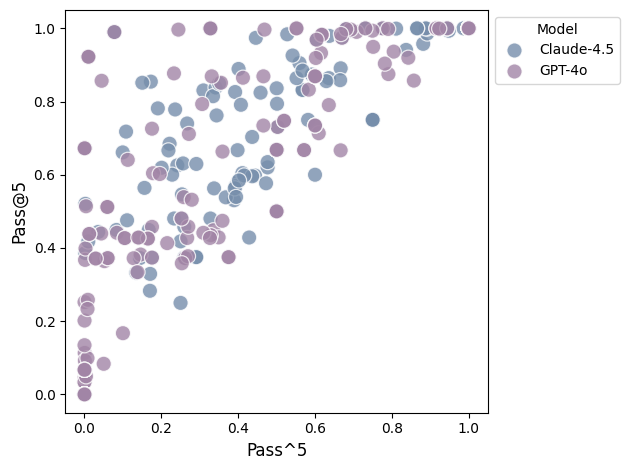

In [86]:
scatter_plot(df, x="pass^5", y="pass@5", hue="model")

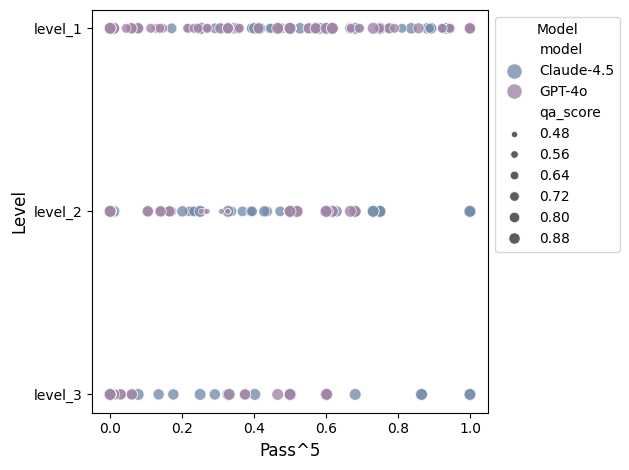

In [65]:
scatter_plot(df, x="pass^5", y="level", hue="model")

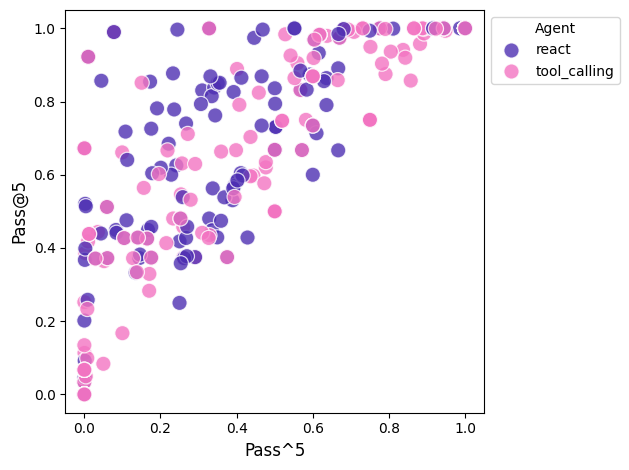

In [74]:
scatter_plot(df, x="pass^5", y="pass@5", hue="agent")

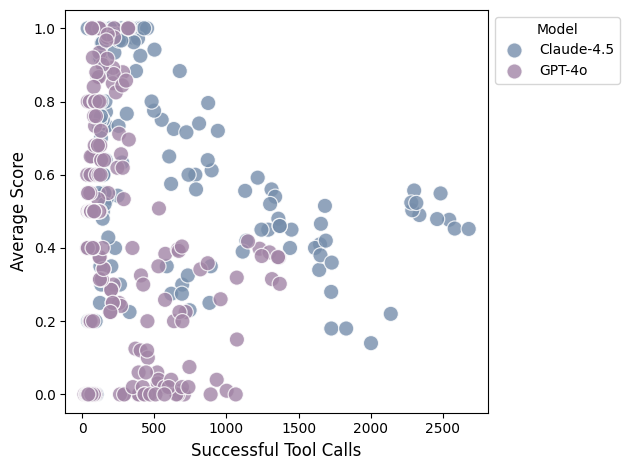

In [88]:
scatter_plot(df, x="successful_tool_calls", y="average_score", hue="model")

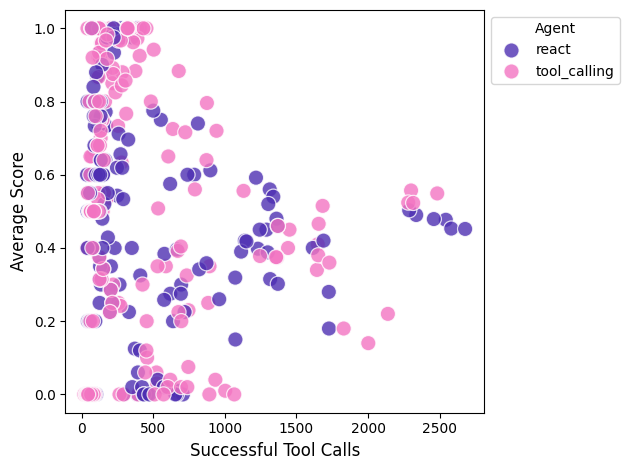

In [90]:
scatter_plot(df, x="successful_tool_calls", y="average_score", hue="agent")

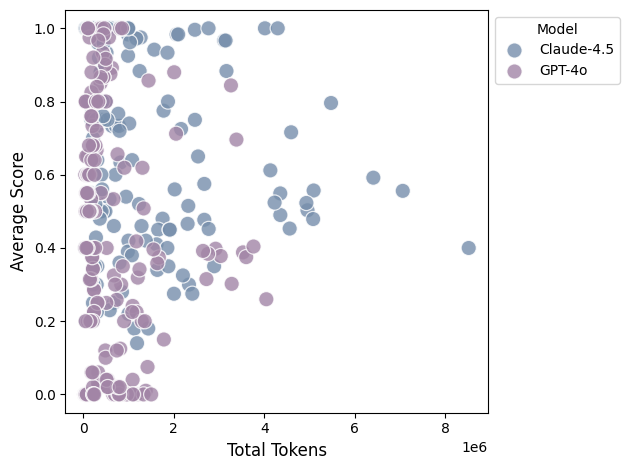

In [91]:
scatter_plot(df, x="total_tokens", y="average_score", hue="model")

In [1]:
scatter_plot(df, x="total_tokens", y="average_score", hue="agent")

NameError: name 'scatter_plot' is not defined

In [8]:
df.columns

Index(['model', 'environment', 'agent', 'subtype', 'level', 'verbosity',
       'task_type', 'prompt_tokens', 'completion_tokens', 'total_tokens',
       'average_score', 'overall_success_rate', 'pass@1', 'pass@2', 'pass@3',
       'pass@4', 'pass@5', 'pass^1', 'pass^2', 'pass^3', 'pass^4', 'pass^5',
       'total_tasks', 'tool_verbosity', 'total_tool_calls',
       'successful_tool_calls', 'failed_tool_calls', 'surrendered_trials',
       'total_tool_execution_duration', 'total_benchmark_duration',
       'qa_score'],
      dtype='object')

0      1360
1      2376
2      1139
3      2563
4      1315
       ... 
487     606
488     633
489     733
490     721
491     796
Name: total_tool_calls, Length: 492, dtype: int64

In [21]:
normalized_tool_calls = df['successful_tool_calls']/df['total_tool_calls']

In [22]:

def scatter_plot_v2(data,x, y, hue,size=None):
    plot = sns.scatterplot(
                    data=data,
                    x=x,
                    y=y,
                    hue=hue,
                    palette=COLOR_PALETTE,
                    s=120,
                    alpha=0.8,
                    edgecolor="w",
                    size=size
                )
    plot.set_xlabel(x.replace("_", " ").title(), fontsize=12)
    plot.set_ylabel(y.replace("_", " ").title(), fontsize=12)
    plot.legend(
        title=hue.title(), bbox_to_anchor=(1, 1), loc="upper left", fontsize=10
    )
    plt.tight_layout()
    

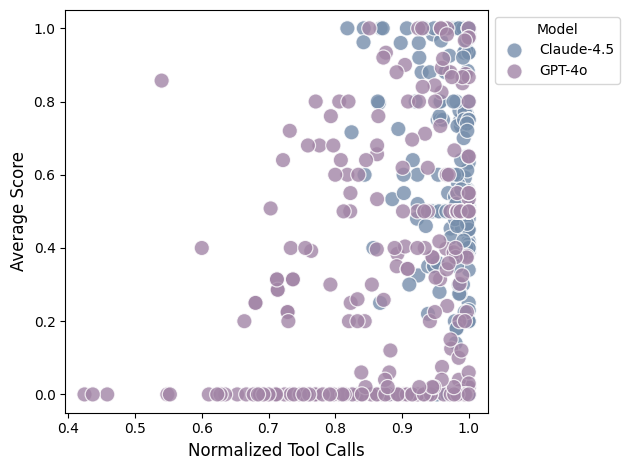

In [23]:
df_plot = df.copy()
df_plot['normalized_tool_calls'] = normalized_tool_calls
scatter_plot_v2(df_plot, x='normalized_tool_calls', y='average_score', hue='model')


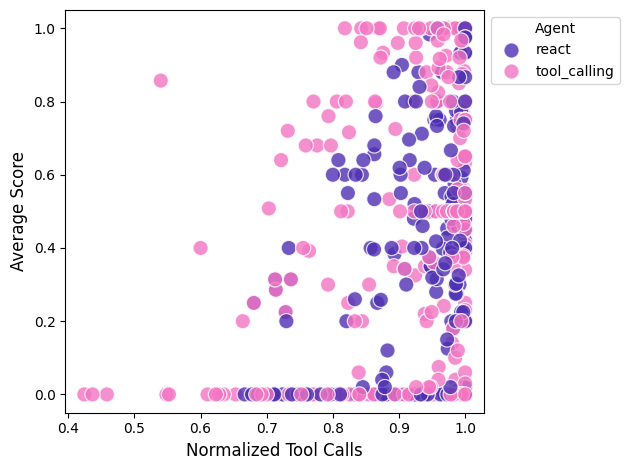

In [24]:
scatter_plot_v2(df_plot, x='normalized_tool_calls', y='average_score', hue='agent')


In [27]:
df.columns

Index(['model', 'environment', 'agent', 'subtype', 'level', 'verbosity',
       'task_type', 'prompt_tokens', 'completion_tokens', 'total_tokens',
       'average_score', 'overall_success_rate', 'pass@1', 'pass@2', 'pass@3',
       'pass@4', 'pass@5', 'pass^1', 'pass^2', 'pass^3', 'pass^4', 'pass^5',
       'total_tasks', 'tool_verbosity', 'total_tool_calls',
       'successful_tool_calls', 'failed_tool_calls', 'surrendered_trials',
       'total_tool_execution_duration', 'total_benchmark_duration',
       'qa_score'],
      dtype='object')

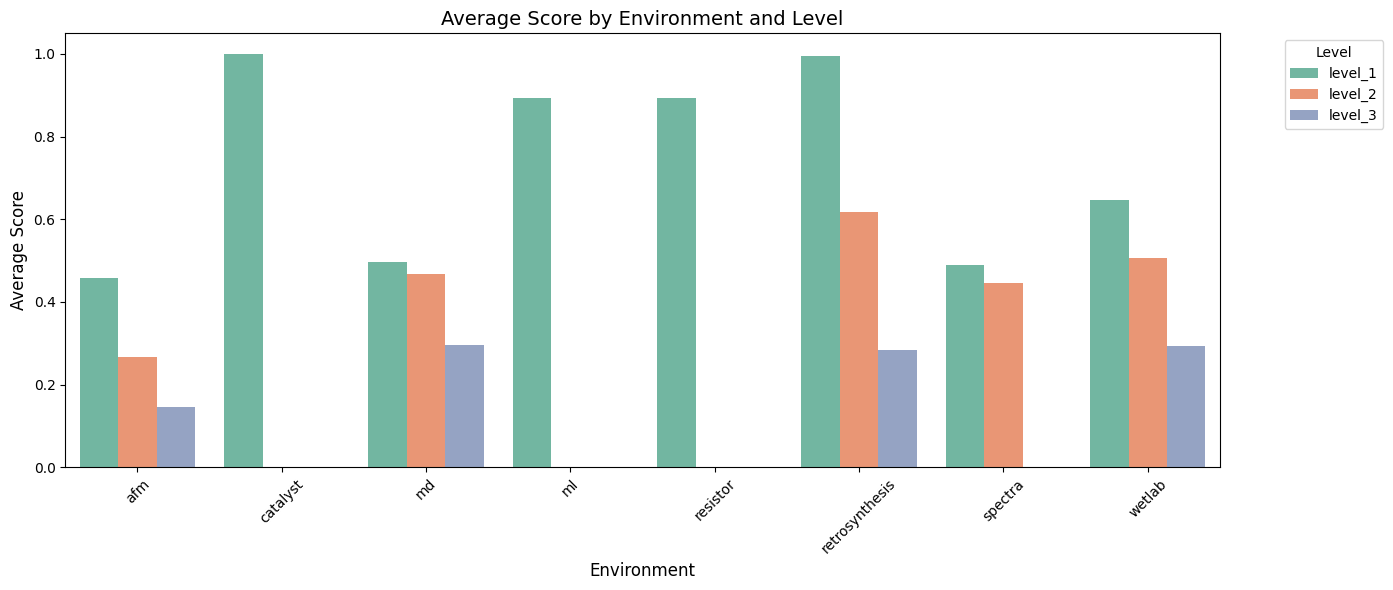

In [ ]:
# plot average_score for different environment level combination
fig, ax = plt.subplots(figsize=(14, 6))

# Group by environment and level, calculate mean average_score
plot_data = df[(df["model"] == "Claude-4.5") & (df["agent"] == "react")].groupby(["environment", "level"])["average_score"].mean().reset_index()

# Create bar plot
sns.barplot(data=plot_data, x='environment', y='average_score', hue='level', ax=ax, palette='Set2')

ax.set_xlabel('Environment', fontsize=12)
ax.set_ylabel('Average Score', fontsize=12)
ax.set_title('Average Score by Environment and Level', fontsize=14)
ax.legend(title='Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression  # For interpolation if levels are numerical

# Assume df is your DataFrame
# Filter for Claude model
df_claude = df[df['model'].str.contains('Claude', case=False)]

# Compute mean scores per group
summary = df_claude.groupby(['environment', 'level', 'agent'])['average_score'].mean().reset_index()

# Define target score (e.g., 0.5 for medium difficulty)
target_score = 0.5

# Function to select level per environment-agent
def select_level(group, target):
    group['diff'] = np.abs(group['average_score'] - target)
    selected = group.loc[group['diff'].idxmin()]
    return selected

# Select for each environment-agent
selections = summary.groupby(['environment', 'agent']).apply(select_level, target=target_score).reset_index(drop=True)

# If levels are numerical, optionally interpolate for finer calibration
# Example: Assume levels are int, fit linear model
def interpolate_level(env_data, target):
    if len(env_data) < 2:
        return env_data.iloc[0]['level']  # Not enough data
    model = LinearRegression()
    X = env_data['level'].values.reshape(-1, 1)
    y = env_data['average_score'].values
    model.fit(X, y)
    # Solve for level where score = target
    pred_level = (target - model.intercept_) / model.coef_[0]
    # Clamp to available levels
    avail_levels = env_data['level'].unique()
    closest_level = min(avail_levels, key=lambda l: abs(l - pred_level))
    return closest_level

# Apply interpolation if desired (replace selections)
# selections['interpolated_level'] = summary.groupby(['environment', 'agent']).apply(interpolate_level, target=target_score)

# Optimize for low variance across environments
# Example: For react agent, compute score variance of selections
react_selections = selections[selections['agent'] == 'react']
score_variance = react_selections['average_score'].var()
print(f"Score variance across environments (react): {score_variance}")

# Output table
print(selections[['environment', 'agent', 'level', 'average_score']])

Score variance across environments (react): 0.049492662832262536
       environment         agent    level  average_score
0              afm         react  level_1       0.457143
1              afm  tool_calling  level_1       0.800000
2         catalyst         react  level_1       1.000000
3         catalyst  tool_calling  level_1       0.993651
4               md         react  level_1       0.497778
5               md  tool_calling  level_2       0.521667
6               ml         react  level_1       0.894444
7               ml  tool_calling  level_1       0.858333
8         resistor         react  level_1       0.893056
9         resistor  tool_calling  level_1       0.813889
10  retrosynthesis         react  level_2       0.617333
11  retrosynthesis  tool_calling  level_3       0.341667
12         spectra         react  level_1       0.488333
13         spectra  tool_calling  level_1       0.455167
14          wetlab         react  level_2       0.506667
15          wetlab  too

/var/folders/tw/1gbrp83s7273pmjr95nyvj800000gn/T/ipykernel_9701/3859957086.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  selections = summary.groupby(['environment', 'agent']).apply(select_level, target=target_score).reset_index(drop=True)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression  # For interpolation if levels are numerical

# Assume df is your DataFrame
# Filter for Claude model (adjust regex if name varies)
df_claude = df[df['model'].str.contains('Claude', case=False)]
# Compute mean scores averaged across agents
summary_avg_agents = df_claude.groupby(['environment', 'level'])['average_score'].mean().reset_index()

# Compute mean scores per group
summary = df_claude.groupby(['environment', 'level', 'agent'])['average_score'].mean().reset_index()

# Compute global mean as target_score
target_score = summary['average_score'].median()
print(f"Computed target_score (global mean): {target_score}")

# Function to select level per environment-agent
def select_level(group, target):
    group['diff'] = np.abs(group['average_score'] - target)
    selected = group.loc[group['diff'].idxmin()]
    return selected

# Select for each environment-agent
selections = summary.groupby(['environment', 'agent']).apply(select_level, target=target_score).reset_index(drop=True)

# If levels are numerical, optionally interpolate for finer calibration
# Example: Assume levels are int, fit linear model
def interpolate_level(env_data, target):
    if len(env_data) < 2:
        return env_data.iloc[0]['level']  # Not enough data
    model = LinearRegression()
    X = env_data['level'].values.reshape(-1, 1)
    y = env_data['average_score'].values
    model.fit(X, y)
    # Solve for level where score = target
    pred_level = (target - model.intercept_) / model.coef_[0]
    # Clamp to available levels
    avail_levels = env_data['level'].unique()
    closest_level = min(avail_levels, key=lambda l: abs(l - pred_level))
    return closest_level

# Apply interpolation if desired (uncomment and replace selections['level'] if using)
# selections['interpolated_level'] = summary.groupby(['environment', 'agent']).apply(interpolate_level, target=target_score)

# Optimize for low variance across environments
# Example: Compute score variance of all selections
score_variance = selections['average_score'].var()
print(f"Score variance across selected levels: {score_variance}")

# Output table of selections
print(selections[['environment', 'agent', 'level', 'average_score']])

Computed target_score (global mean): 0.4930555555555556
Score variance across selected levels: 0.05246214519610313
       environment         agent    level  average_score
0              afm         react  level_1       0.457143
1              afm  tool_calling  level_1       0.800000
2         catalyst         react  level_1       1.000000
3         catalyst  tool_calling  level_1       0.993651
4               md         react  level_1       0.497778
5               md  tool_calling  level_3       0.472222
6               ml         react  level_1       0.894444
7               ml  tool_calling  level_1       0.858333
8         resistor         react  level_1       0.893056
9         resistor  tool_calling  level_1       0.813889
10  retrosynthesis         react  level_2       0.617333
11  retrosynthesis  tool_calling  level_3       0.341667
12         spectra         react  level_1       0.488333
13         spectra  tool_calling  level_1       0.455167
14          wetlab         rea

/var/folders/tw/1gbrp83s7273pmjr95nyvj800000gn/T/ipykernel_9701/3067035723.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  selections = summary.groupby(['environment', 'agent']).apply(select_level, target=target_score).reset_index(drop=True)


In [49]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression  # For interpolation if levels are numerical

# Assume df is your DataFrame
# Filter for Claude model (adjust regex if name varies)
df_claude = df[df['model'].str.contains('Claude', case=False)]
# Compute mean scores averaged across agents
summary= df_claude.groupby(['environment', 'level'])['average_score'].mean().reset_index()



# Compute global mean as target_score
target_score = summary['average_score'].mean()
print(f"Computed target_score (global mean): {target_score}")

# Function to select level per environment-agent
def select_level(group, target):
    group['diff'] = np.abs(group['average_score'] - target)
    selected = group.loc[group['diff'].idxmin()]
    return selected

# Select for each environment-agent
selections = summary.groupby(['environment']).apply(select_level, target=target_score).reset_index(drop=True)

# If levels are numerical, optionally interpolate for finer calibration
# Example: Assume levels are int, fit linear model
def interpolate_level(env_data, target):
    if len(env_data) < 2:
        return env_data.iloc[0]['level']  # Not enough data
    model = LinearRegression()
    X = env_data['level'].values.reshape(-1, 1)
    y = env_data['average_score'].values
    model.fit(X, y)
    # Solve for level where score = target
    pred_level = (target - model.intercept_) / model.coef_[0]
    # Clamp to available levels
    avail_levels = env_data['level'].unique()
    closest_level = min(avail_levels, key=lambda l: abs(l - pred_level))
    return closest_level

# Apply interpolation if desired (uncomment and replace selections['level'] if using)
# selections['interpolated_level'] = summary.groupby(['environment', 'agent']).apply(interpolate_level, target=target_score)

# Optimize for low variance across environments
# Example: Compute score variance of all selections
score_variance = selections['average_score'].var()
print(f"Score variance across selected levels: {score_variance}")

# Output table of selections
print(selections[['environment',  'level', 'average_score']])

Computed target_score (global mean): 0.5397159197012138
Score variance across selected levels: 0.04312290548373782
      environment    level  average_score
0             afm  level_1       0.571429
1        catalyst  level_1       0.996825
2              md  level_1       0.518333
3              ml  level_1       0.876389
4        resistor  level_1       0.853472
5  retrosynthesis  level_2       0.662250
6         spectra  level_1       0.471750
7          wetlab  level_2       0.453333


/var/folders/tw/1gbrp83s7273pmjr95nyvj800000gn/T/ipykernel_9701/3705682508.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  selections = summary.groupby(['environment']).apply(select_level, target=target_score).reset_index(drop=True)


In [ ]:
## correlation

In [10]:
df = pd.read_csv("combined_corral_results.csv")

In [6]:
df.columns

Index(['model', 'environment', 'agent', 'subtype', 'level', 'verbosity',
       'task_type', 'prompt_tokens', 'completion_tokens', 'total_tokens',
       'average_score', 'overall_success_rate', 'pass@1', 'pass@2', 'pass@3',
       'pass@4', 'pass@5', 'pass^1', 'pass^2', 'pass^3', 'pass^4', 'pass^5',
       'total_tasks', 'tool_verbosity', 'total_tool_calls',
       'successful_tool_calls', 'failed_tool_calls', 'surrendered_trials',
       'total_tool_execution_duration', 'total_benchmark_duration',
       'qa_score'],
      dtype='object')

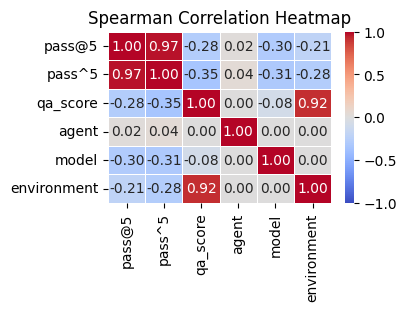

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'df' is your pandas DataFrame with the provided columns.
# Note: 'scaffold' is not in the listed columns; if it's a typo (e.g., for 'subtype') or an additional column,
# replace or add it to the 'cols' list and the encoding loop as needed.
# If 'scaffold' doesn't exist, the script will raise an error—adjust accordingly.

# Filter the DataFrame based on constraints
df_filtered = df[(df['task_type'] == 'tasks') ] #& (df['verbosity'] == 'workflow')]

# Select relevant columns
cols = ['pass@5', 'pass^5', 'qa_score', 'agent', 'model', 'environment']  # Adjust 'scaffold' if needed

# Create a copy for encoding
df_encoded = df_filtered[cols].copy()

# Encode categorical variables to numerical for correlation (assuming 'model', 'environment', 'level', 'scaffold' are categorical)
# If 'level' is already numerical/ordinal, you can remove it from this loop.
categorical_cols = ['model', 'environment', 'agent']  # Adjust as needed
for col in categorical_cols:
    df_encoded[col] = pd.factorize(df_encoded[col])[0]

# Compute Spearman correlation matrix
corr_matrix = df_encoded.corr(method='spearman')

# Create the heatmap
plt.figure(figsize=(ONE_COL_WIDTH_INCH*1.2, ONE_COL_GOLDEN_RATIO_HEIGHT_INCH*1.2))  # Adjust size as needed
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)
plt.title('Spearman Correlation Heatmap')
plt.show()

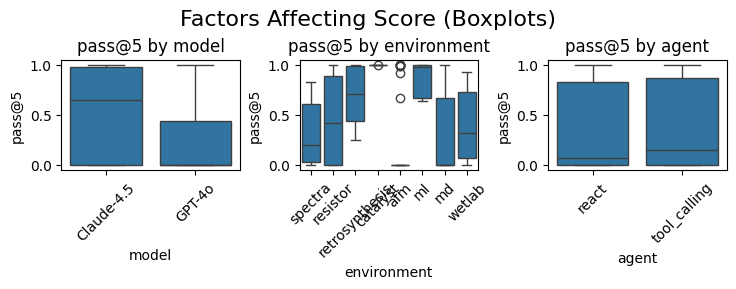

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'df' is your pandas DataFrame with the provided columns.
# Filter the DataFrame based on constraints
df_filtered = df[(df['task_type'] == 'tasks') ]

# Select key score and factors (adjust if 'scaffold' is meant to be 'subtype' or another column)
score_col = 'pass@5'  # Change to 'qa_score' if preferred
factors = ['model', 'environment', 'agent']  # Include 'subtype' as it seems key from your plot

# Create subplots for each factor
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(TWO_COL_WIDTH_INCH, 1.5*ONE_COL_GOLDEN_RATIO_HEIGHT_INCH), constrained_layout=True)
axes = axes.flatten()  # Flatten for easy iteration

for i, factor in enumerate(factors):
    if factor in df_filtered.columns:
        sns.boxplot(data=df_filtered, x=factor, y=score_col, ax=axes[i])
        axes[i].set_title(f'{score_col} by {factor}')
        axes[i].tick_params(axis='x', rotation=45)
    else:
        axes[i].text(0.5, 0.5, f'{factor} not in columns', ha='center', va='center')
        axes[i].axis('off')

# Hide extra axes if fewer factors
for j in range(len(factors), len(axes)):
    axes[j].axis('off')

plt.suptitle('Factors Affecting Score (Boxplots)', fontsize=16)
plt.show()


In [47]:
df = pd.read_csv("combined_corral_results.csv")

In [66]:
import pandas as pd
import statsmodels.formula.api as smf

df = pd.read_csv("combined_corral_results.csv")

# pick one
df_filtered = df.copy()
# df_filtered = df[(df['task_type'] == 'tasks')].copy()
# df_filtered = df[(df['task_type'] == 'tasks') & (df['verbosity'] == 'comprehensive')].copy()

df_filtered = df_filtered.rename(columns={'pass@5': 'pass_at_5'})

# keep only rows needed by the model; MixedLM/patsy will otherwise drop them internally
needed = ["pass_at_5", "model", "agent", "qa_score", "task_type", "verbosity", "environment"]
df_filtered = df_filtered.dropna(subset=needed).reset_index(drop=True)

# IMPORTANT: pass groups by *column name* so it stays aligned after patsy processing
md = smf.mixedlm(
    "pass_at_5 ~ C(model) + C(agent) + qa_score + C(task_type) + C(verbosity)",
    data=df_filtered,
    groups="environment"
)

res = md.fit(reml=True, method="lbfgs")
print(res.summary())


                  Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       pass_at_5
No. Observations:       396           Method:                   REML     
No. Groups:             6             Scale:                    0.0828   
Min. group size:        24            Log-Likelihood:           -91.1297 
Max. group size:        216           Converged:                Yes      
Mean group size:        66.0                                             
-------------------------------------------------------------------------
                              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                      0.076    0.244   0.313 0.754 -0.402  0.555
C(model)[T.GPT-4o]            -0.128    0.032  -4.054 0.000 -0.191 -0.066
C(agent)[T.tool_calling]       0.021    0.029   0.726 0.468 -0.036  0.078
C(task_type)[T.tasks]         -0.344    0.029 -11.858 0.

/Users/n0w0f/miniconda3/envs/corral/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


In [68]:
md2 = smf.mixedlm(
    "pass_at_5 ~ C(model) + C(agent) + qa_score",
    data=df_filtered,
    groups="environment",
    re_formula="~C(agent)"
)
res2 = md2.fit(reml=True, method="lbfgs")
print(res2.summary())


                        Mixed Linear Model Regression Results
Model:                      MixedLM           Dependent Variable:           pass_at_5
No. Observations:           396               Method:                       REML     
No. Groups:                 6                 Scale:                        0.1126   
Min. group size:            24                Log-Likelihood:               -144.1697
Max. group size:            216               Converged:                    Yes      
Mean group size:            66.0                                                     
-------------------------------------------------------------------------------------
                                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------
Intercept                                  -0.150    0.268 -0.559 0.576 -0.676  0.376
C(model)[T.GPT-4o]                         -0.119    0.037 -3.214 0.001 -0.191

/Users/n0w0f/miniconda3/envs/corral/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/n0w0f/miniconda3/envs/corral/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


Model comparison (ML): AIC M0=171.00, AIC M1=164.86  -> best = M1
                  Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       pass_at_5
No. Observations:       396           Method:                   REML     
No. Groups:             6             Scale:                    0.0793   
Min. group size:        24            Log-Likelihood:           -86.6462 
Max. group size:        216           Converged:                Yes      
Mean group size:        66.0                                             
-------------------------------------------------------------------------
                              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                      0.863    0.112   7.677 0.000  0.643  1.083
C(model)[T.GPT-4o]            -0.111    0.032  -3.461 0.001 -0.174 -0.048
C(agent)[T.tool_calling]       0.021    0.028   0.755 0.450 -0.0

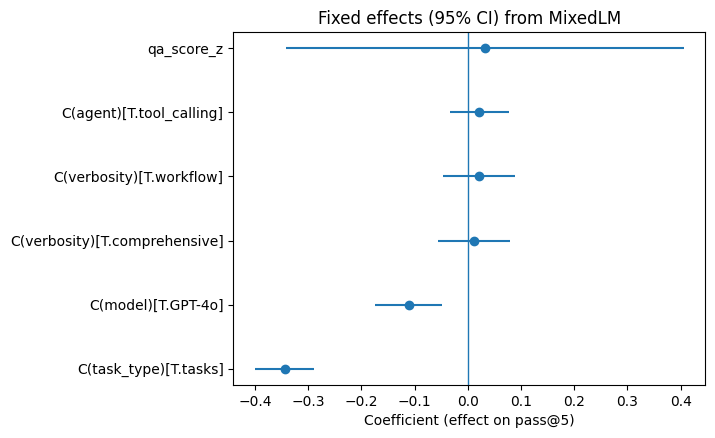

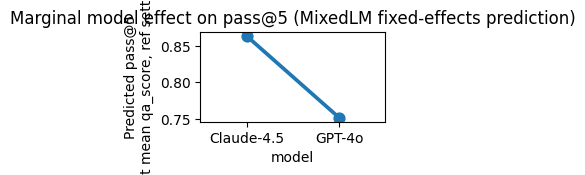

In [80]:
# Best-fit (practical) analysis script for your use case:
# - Mixed-effects model: environment as random intercept (dominant difficulty driver)
# - Includes key fixed effects: model, agent, qa_score, task_type, verbosity
# - Adds optional env-varying qa_score slope if it improves fit (AIC)
# - Produces effect plots:
#   1) marginal effect of qa_score by environment (predicted lines)
#   2) estimated model effects (fixed-effect coefficients with 95% CI)
#   3) predicted pass@5 by model (marginal means at typical settings)

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore", category=UserWarning)

# -----------------------------
# 1) Load + clean
# -----------------------------
df = pd.read_csv("combined_corral_results.csv")

df = df.rename(columns={"pass@5": "pass_at_5"}).copy()

needed = ["pass_at_5", "model", "agent", "qa_score", "task_type", "verbosity", "environment"]
df = df.dropna(subset=needed).reset_index(drop=True)

# (Optional but recommended) standardize qa_score for stability and interpretability
df["qa_score_z"] = (df["qa_score"] - df["qa_score"].mean()) / df["qa_score"].std(ddof=0)

# Ensure categorical dtype (keeps plotting + summaries clean)
for c in ["model", "agent", "task_type", "verbosity", "environment"]:
    df[c] = df[c].astype("category")

# -----------------------------
# 2) Fit "best" mixed model by comparing two sensible candidates
#   M0: random intercept by environment
#   M1: random intercept + random slope of qa_score by environment
# Choose by AIC (fit with ML for comparison), then refit final with REML.
# -----------------------------
formula = "pass_at_5 ~ C(model) + C(agent) + C(task_type) + C(verbosity) + qa_score_z"

# Fit with ML for model comparison
m0_ml = smf.mixedlm(formula, data=df, groups="environment")
r0_ml = m0_ml.fit(reml=False, method="lbfgs")

m1_ml = smf.mixedlm(formula, data=df, groups="environment", re_formula="~qa_score_z")
r1_ml = m1_ml.fit(reml=False, method="lbfgs")

best = "M1" if r1_ml.aic < r0_ml.aic else "M0"
print(f"Model comparison (ML): AIC M0={r0_ml.aic:.2f}, AIC M1={r1_ml.aic:.2f}  -> best = {best}")

# Refit best model with REML for final inference
if best == "M1":
    m_final = smf.mixedlm(formula, data=df, groups="environment", re_formula="~qa_score_z")
else:
    m_final = smf.mixedlm(formula, data=df, groups="environment")

r_final = m_final.fit(reml=True, method="lbfgs")
print(r_final.summary())

# -----------------------------
# 3) Build a prediction grid for effect plots
#    We'll hold categorical vars at typical/reference levels and vary qa_score.
# -----------------------------
# Choose representative settings:
ref_model = df["model"].cat.categories[0]
ref_agent = df["agent"].cat.categories[0]
ref_task  = df["task_type"].cat.categories[0]
ref_verb  = df["verbosity"].cat.categories[0]

qa_grid = np.linspace(df["qa_score_z"].quantile(0.05), df["qa_score_z"].quantile(0.95), 40)

pred_rows = []
for env in df["environment"].cat.categories:
    for qz in qa_grid:
        pred_rows.append({
            "environment": env,
            "model": ref_model,
            "agent": ref_agent,
            "task_type": ref_task,
            "verbosity": ref_verb,
            "qa_score_z": qz
        })
pred_df = pd.DataFrame(pred_rows)
for c in ["model", "agent", "task_type", "verbosity", "environment"]:
    pred_df[c] = pred_df[c].astype("category")

# statsmodels MixedLM predict() returns fitted values using fixed effects;
# to show environment-specific curves, we add random effects (BLUPs) when available.
fe_pred = r_final.predict(pred_df)

pred_df["pred_fixed"] = fe_pred

# Add random effects contribution (if present)
# random_effects is a dict: {group_name: array/series of RE params}
# For random intercept only: one term.
# For random intercept + slope: intercept + slope*qa_score_z.
pred_with_re = []
re_dict = r_final.random_effects

has_slope = (best == "M1")
for i, row in pred_df.iterrows():
    env = row["environment"]
    re = re_dict.get(env, None)
    y = row["pred_fixed"]
    if re is not None:
        # re can be Series-like with index or ndarray
        if hasattr(re, "index"):
            # named
            if has_slope:
                # common names: "Group" intercept + "qa_score_z"
                # be defensive:
                intercept = float(re.iloc[0])
                slope = float(re.iloc[1])
                y = y + intercept + slope * row["qa_score_z"]
            else:
                y = y + float(re.iloc[0])
        else:
            # ndarray
            if has_slope:
                y = y + float(re[0]) + float(re[1]) * row["qa_score_z"]
            else:
                y = y + float(re[0])
    pred_with_re.append(y)

pred_df["pred_env"] = pred_with_re

# Convert qa_score_z back to raw for x-axis labels
pred_df["qa_score_raw"] = pred_df["qa_score_z"] * df["qa_score"].std(ddof=0) + df["qa_score"].mean()


# -----------------------------
# 5) Plot 2: Fixed-effect coefficient plot (with 95% CI)
# -----------------------------
fe = r_final.fe_params
ci = r_final.conf_int().loc[fe.index]
coef_df = pd.DataFrame({
    "term": fe.index,
    "coef": fe.values,
    "lo": ci[0].values,
    "hi": ci[1].values
})

# Drop intercept to focus on effects
coef_df = coef_df[coef_df["term"] != "Intercept"].copy()
coef_df = coef_df.sort_values("coef")

plt.figure(figsize=(TWO_COL_WIDTH_INCH, TWO_COL_GOLDEN_RATIO_HEIGHT_INCH))
plt.hlines(y=coef_df["term"], xmin=coef_df["lo"], xmax=coef_df["hi"])
plt.plot(coef_df["coef"], coef_df["term"], marker="o", linestyle="None")
plt.axvline(0, linewidth=1)
plt.xlabel("Coefficient (effect on pass@5)")
plt.ylabel("")
plt.title("Fixed effects (95% CI) from MixedLM")
plt.tight_layout()
plt.show()

# -----------------------------
# 6) Plot 3: Marginal predicted pass@5 by model (holding others fixed)
# -----------------------------
model_grid = df["model"].cat.categories
mm_rows = []
for m in model_grid:
    mm_rows.append({
        "environment": df["environment"].cat.categories[0],  # fixed env for baseline (random intercept added below)
        "model": m,
        "agent": ref_agent,
        "task_type": ref_task,
        "verbosity": ref_verb,
        "qa_score_z": 0.0,  # mean qa_score
    })
mm_df = pd.DataFrame(mm_rows)
for c in ["model", "agent", "task_type", "verbosity", "environment"]:
    mm_df[c] = mm_df[c].astype("category")

mm_df["pred"] = r_final.predict(mm_df)

plt.figure(figsize=(ONE_COL_WIDTH_INCH, ONE_COL_GOLDEN_RATIO_HEIGHT_INCH))
sns.pointplot(data=mm_df, x="model", y="pred")
plt.xlabel("model")
plt.ylabel("Predicted pass@5\n(at mean qa_score, ref settings)")
plt.title("Marginal model effect on pass@5 (MixedLM fixed-effects prediction)")
plt.tight_layout()
plt.show()


In [91]:
df.environment.unique()

array(['spectra', 'resistor', 'catalyst', 'afm', 'ml', 'md'], dtype=object)

In [100]:
qa_df = pd.read_csv("/Users/n0w0f/git/n0w0f_2026/mat-agent-bench/reports_v2/qa/qa_scores.csv")

In [101]:
qa_df

,Unnamed: 0,item_id,model_id,env_id,correct
0,0,0fd01b97-5f43-503f-8659-61636e47397e-000-000-068,Claude-4.5,spectra,0.0
1,1,c2b72291-5885-5578-adae-da7182aab0f6-000-000-051,Claude-4.5,spectra,1.0
2,2,4fc849ac-e14a-52af-9fad-9e381a1ee8a5-000-000-018,Claude-4.5,spectra,0.0
3,3,b74f2fb6-06e8-5ce8-88fc-7851c8c2076c-000-000-041,Claude-4.5,spectra,1.0
4,4,5f5bf723-48f6-5568-85af-1d3e198b830a-000-000-078,Claude-4.5,spectra,1.0
...,...,...,...,...,...
843,843,1369676d-332a-5c1b-8eb6-d2a25d805b6c,gpt-4o,retrosynthesis,0.0
844,844,4e11b7ff-9203-5c41-8e32-7d639ef84961,gpt-4o,retrosynthesis,0.0
845,845,194acfa5-5b46-584e-aeb0-7d3eb2e887c0,gpt-4o,retrosynthesis,0.0
846,846,9f8d3d83-c680-5cd1-bf23-532df03973f7,gpt-4o,retrosynthesis,1.0
